In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv(
    "processed/tomato_daily.csv",
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
print(df.head())
print(df.tail())

(1849, 2)
        date   price
0 2020-01-01  1150.0
1 2020-01-02  1100.0
2 2020-01-03  1125.0
3 2020-01-04  1200.0
4 2020-01-05  1350.0
           date   price
1844 2025-10-25  2100.0
1845 2025-10-26  2000.0
1846 2025-10-27  2000.0
1847 2025-10-28  1950.0
1848 2025-10-29  1950.0


In [4]:
train_df = df[df["date"] < "2024-01-01"].copy()
val_df = df[
    (df["date"] >= "2024-01-01") &
    (df["date"] < "2025-01-01")
].copy()
test_df = df[df["date"] >= "2025-01-01"].copy()

print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

print("\nTrain:", train_df["date"].min(), "→", train_df["date"].max())
print("Val  :", val_df["date"].min(), "→", val_df["date"].max())
print("Test :", test_df["date"].min(), "→", test_df["date"].max())

TRAIN: (1280, 2)
VALIDATION: (301, 2)
TEST: (268, 2)

Train: 2020-01-01 00:00:00 → 2023-12-31 00:00:00
Val  : 2024-01-01 00:00:00 → 2024-12-31 00:00:00
Test : 2025-01-01 00:00:00 → 2025-10-29 00:00:00


In [5]:
train_prices = train_df["price"].values.reshape(-1, 1)
val_prices = val_df["price"].values.reshape(-1, 1)
test_prices = test_df["price"].values.reshape(-1, 1)

print(train_prices.shape)
print(val_prices.shape)
print(test_prices.shape)

(1280, 1)
(301, 1)
(268, 1)


In [6]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_prices)
val_scaled = scaler.transform(val_prices)
test_scaled = scaler.transform(test_prices)

print(
    "Train range:",
    train_scaled.min(),
    "→",
    train_scaled.max()
)

Train range: 0.0 → 1.0


In [7]:
scaler.fit_transform(train_prices)

array([[0.09090909],
       [0.08369408],
       [0.08730159],
       ...,
       [0.0974026 ],
       [0.09487734],
       [0.09307359]], shape=(1280, 1))

In [10]:
back = 30
days = 7

def create_sequences(data, back=30, days=7):
    X = []
    y = []

    for i in range(back, len(data) - days + 1):
        X.append(data[i - back:i])
        y.append(data[i:i + days])

    return np.array(X), np.array(y)

In [11]:
X_train, y_train = create_sequences(
    train_scaled,
    back,
    days
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (1244, 30, 1)
y_train: (1244, 7, 1)


In [12]:
val = np.concatenate([
    train_scaled[-back:],
    val_scaled
])

In [13]:
test = np.concatenate([
    val_scaled[-back:],
    test_scaled
])

In [15]:
X_val, y_val = create_sequences(
    val,
    back,
    days
)
X_test, y_test = create_sequences(
    test,
    back,
    days
)

In [16]:
print("X_val :", X_val.shape)
print("y_val :", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_val : (295, 30, 1)
y_val : (295, 7, 1)
X_test: (262, 30, 1)
y_test: (262, 7, 1)


In [17]:
y_train = y_train.reshape(
    y_train.shape[0],
    days
)

In [18]:
y_val = y_val.reshape(
    y_val.shape[0],
    days
)

In [19]:
y_test = y_test.reshape(
    y_test.shape[0],
    days
)

In [20]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1244, 30, 1)
y_train: (1244, 7)
X_val: (295, 30, 1)
y_val: (295, 7)
X_test: (262, 30, 1)
y_test: (262, 7)


In [22]:
model = Sequential([
    LSTM(
        64,
        input_shape=(back, 1)
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(days)
])


C:\Users\Kanishka\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,207 (75.03 KB)

 Trainable params: 19,207 (75.03 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 0.0138 - mae: 0.0735 - val_loss: 0.0107 - val_mae: 0.0714
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0052 - mae: 0.0422 - val_loss: 0.0053 - val_mae: 0.0530
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0045 - mae: 0.0377 - val_loss: 0.0047 - val_mae: 0.0479
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0040 - mae: 0.0356 - val_loss: 0.0041 - val_mae: 0.0451
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0038 - mae: 0.0326 - val_loss: 0.0046 - val_mae: 0.0478
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0036 - mae: 0.0328 - val_loss: 0.0037 - val_mae: 0.0425
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0033 - mae: 0.0311 - val_loss: 0.0041 - val_mae: 0.0441
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0031 - mae: 0.0301 - val_loss: 0.0035 - val_mae: 0.0406
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - lo

In [27]:
val_pred_scaled = model.predict(X_val)
print("Prediction shape:", val_pred_scaled.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Prediction shape: (295, 7)


In [28]:
val_pred = scaler.inverse_transform(
    val_pred_scaled
)

val_actual = scaler.inverse_transform(
    y_val
)

print("Predicted shape:", val_pred.shape)
print("Actual shape:", val_actual.shape)

Predicted shape: (295, 7)
Actual shape: (295, 7)


In [30]:
for h in range(days):

    mae = mean_absolute_error(
        val_actual[:, h],
        val_pred[:, h]
    )

    rmse = np.sqrt(
        mean_squared_error(
            val_actual[:, h],
            val_pred[:, h]
        )
    )

    mape = np.mean(
        np.abs(
            (val_actual[:, h] - val_pred[:, h])
            / val_actual[:, h]
        )
    ) * 100

    print(
        f"Day +{h+1}: "
        f"MAE ₹{mae:.2f} | "
        f"RMSE ₹{rmse:.2f} | "
        f"MAPE {mape:.2f}%"
    )

Day +1: MAE ₹115.37 | RMSE ₹179.99 | MAPE 5.21%
Day +2: MAE ₹166.96 | RMSE ₹248.76 | MAPE 7.51%
Day +3: MAE ₹199.27 | RMSE ₹291.75 | MAPE 9.33%
Day +4: MAE ₹244.90 | RMSE ₹347.22 | MAPE 11.43%
Day +5: MAE ₹302.17 | RMSE ₹403.74 | MAPE 14.92%
Day +6: MAE ₹328.28 | RMSE ₹444.21 | MAPE 15.83%
Day +7: MAE ₹357.77 | RMSE ₹489.90 | MAPE 16.89%


In [31]:
test_pred_scaled = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [32]:
test_pred = scaler.inverse_transform(
    test_pred_scaled
)

In [33]:
test_actual = scaler.inverse_transform(
    y_test
)

In [34]:
for h in range(days):

    mae = mean_absolute_error(
        test_actual[:, h],
        test_pred[:, h]
    )

    rmse = np.sqrt(
        mean_squared_error(
            test_actual[:, h],
            test_pred[:, h]
        )
    )

    mape = np.mean(
        np.abs(
            (test_actual[:, h] - test_pred[:, h])
            / test_actual[:, h]
        )
    ) * 100

    print(
        f"Day +{h+1}: "
        f"MAE ₹{mae:.2f} | "
        f"RMSE ₹{rmse:.2f} | "
        f"MAPE {mape:.2f}%"
    )

Day +1: MAE ₹91.77 | RMSE ₹129.69 | MAPE 6.57%
Day +2: MAE ₹113.53 | RMSE ₹164.89 | MAPE 7.66%
Day +3: MAE ₹155.77 | RMSE ₹207.99 | MAPE 11.29%
Day +4: MAE ₹173.76 | RMSE ₹234.57 | MAPE 11.64%
Day +5: MAE ₹249.97 | RMSE ₹301.92 | MAPE 20.00%
Day +6: MAE ₹258.48 | RMSE ₹319.84 | MAPE 20.11%
Day +7: MAE ₹263.53 | RMSE ₹337.75 | MAPE 20.19%


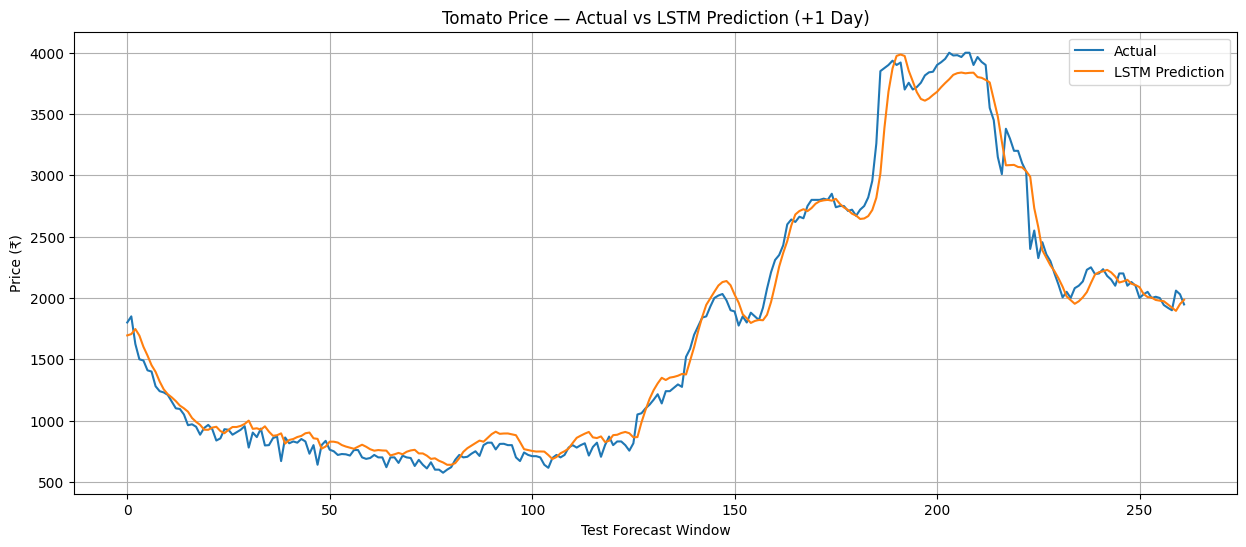

In [35]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_actual[:, 0],
    label="Actual"
)

plt.plot(
    test_pred[:, 0],
    label="LSTM Prediction"
)

plt.title("Tomato Price — Actual vs LSTM Prediction (+1 Day)")
plt.xlabel("Test Forecast Window")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)

plt.show()

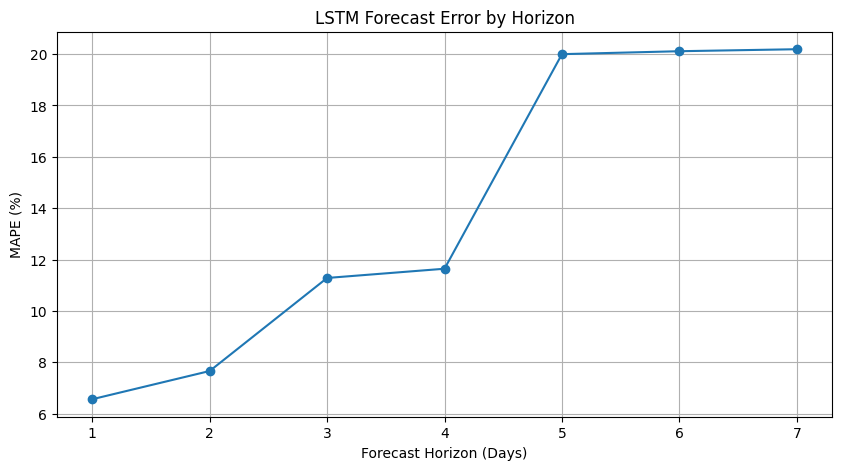

In [38]:
horizons = np.arange(1, days + 1)

mape_values = []

for h in range(days):
    mape = np.mean(
        np.abs(
            (test_actual[:, h] - test_pred[:, h])
            / test_actual[:, h]
        )
    ) * 100

    mape_values.append(mape)


plt.figure(figsize=(10, 5))

plt.plot(
    horizons,
    mape_values,
    marker="o"
)

plt.title("LSTM Forecast Error by Horizon")
plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("MAPE (%)")
plt.xticks(horizons)
plt.grid(True)

plt.show()

In [39]:
model.save("tomato_lstm.keras")

In [40]:
import joblib

joblib.dump(
    scaler,
    "tomato_scaler.pkl"
)

['tomato_scaler.pkl']